In [20]:
# ------------------------------------------------------------
# STEP 1: IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [21]:
# ------------------------------------------------------------
# STEP 2: LOAD THE IRIS DATASET
# ------------------------------------------------------------

# Load the built-in Iris dataset.
iris = load_iris()

# ------------------------------------------------------------
# STEP 3: EXTRACT THE INPUT FEATURES
# ------------------------------------------------------------

X = iris.data

print("Shape of Dataset:")
print(X.shape)

# Display the first five observations.
print("\nFirst Five Observations:")
print(X[:5])

Shape of Dataset:
(150, 4)

First Five Observations:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [22]:
# ------------------------------------------------------------
# STEP 4: STANDARDIZE THE FEATURES
# ------------------------------------------------------------

# Create an object of StandardScaler.
scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)

# Display the first five standardized observations.
print("\nFirst Five Standardized Observations:")
print(X_scaled[:5])


First Five Standardized Observations:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [23]:
# ------------------------------------------------------------
# STEP 5: CREATE THE K-MEANS CLUSTERING MODEL
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# ------------------------------------------------------------
# STEP 6: APPLY K-MEANS CLUSTERING
# ------------------------------------------------------------


clusters = kmeans.fit_predict(X_scaled)

# Display the cluster assigned to every observation.
print("\nCluster Assignments:")
print(clusters)

# ------------------------------------------------------------
# STEP 7: DISPLAY CLUSTER CENTERS
# ------------------------------------------------------------


Cluster Assignments:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [24]:
# cluster_centers_ contains the final centroid coordinates
# in the standardized feature space.
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# ------------------------------------------------------------
# STEP 8: COUNT THE NUMBER OF OBSERVATIONS IN EACH CLUSTER
# ------------------------------------------------------------

# Count how many observations belong to each cluster.
for cluster_number in range(3):
    count = sum(
        clusters == cluster_number
    )

    print(
        "Number of observations in Cluster",
        cluster_number,
        ":",
        count
    )


Cluster Centers:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]
Number of observations in Cluster 0 : 53
Number of observations in Cluster 1 : 50
Number of observations in Cluster 2 : 47


In [25]:
# ------------------------------------------------------------
# STEP 9: APPLY PRINCIPAL COMPONENT ANALYSIS (PCA)
# ------------------------------------------------------------

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

In [26]:
# ------------------------------------------------------------
# STEP 10: DISPLAY PCA RESULTS
# ------------------------------------------------------------

print("\nShape After PCA:")
print(X_pca.shape)

# Display the first five transformed observations.
print("\nFirst Five PCA Observations:")
print(X_pca[:5])

# ------------------------------------------------------------
# STEP 11: DISPLAY EXPLAINED VARIANCE
# ------------------------------------------------------------

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Calculate the total variance represented by the
# two principal components.
total_variance = sum(
    pca.explained_variance_ratio_
)

print("\nTotal Explained Variance:")
print(total_variance)


Shape After PCA:
(150, 2)

First Five PCA Observations:
[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Explained Variance:
0.9581320720000166


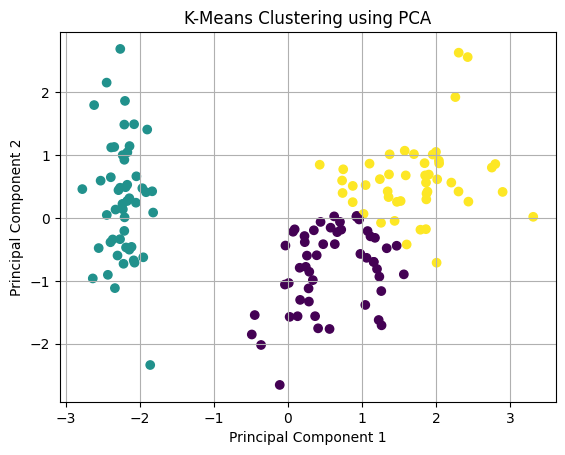

In [27]:
# ------------------------------------------------------------
# STEP 12: VISUALIZE THE CLUSTERS
# ------------------------------------------------------------

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

# Label the X-axis.
plt.xlabel(
    "Principal Component 1"
)

# Label the Y-axis.
plt.ylabel(
    "Principal Component 2"
)

# Give a suitable title to the graph.
plt.title(
    "K-Means Clustering using PCA"
)

# Display grid lines to make the graph easier to understand.
plt.grid(True)

# Display the final graph.
plt.show()

# ============================================================
# END OF PROGRAM
# ============================================================